In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('/kaggle/input/datasets/mennafawzy24/diabetic-dataset/diabetic_data.csv')

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df.shape

(101766, 50)

In [6]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [7]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [8]:
df.replace('?', np.nan, inplace=True)
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
df.duplicated().sum()

np.int64(0)

<div align="center">

# 🩺 Diabetes Readmission Prediction System  
### *From Data Analysis to Machine Learning Deployment*

<img src="https://img.shields.io/badge/Dataset-101K%20Patients-blue?style=for-the-badge">
<img src="https://img.shields.io/badge/Focus-Healthcare%20AI-success?style=for-the-badge">
<img src="https://img.shields.io/badge/Project-ML%20%26%20Deployment-orange?style=for-the-badge">

</div>

---

# 📌 Project Overview

Hospital readmission is one of the most significant challenges in healthcare systems, especially for diabetic patients. Early prediction of patient readmission can help hospitals improve treatment quality, reduce healthcare costs, and enhance patient outcomes.

This project focuses on building a complete **Machine Learning pipeline** using a real-world healthcare dataset containing **over 100,000 diabetic patient records**.

The dataset includes:

- 👨‍⚕️ Patient demographic information  
- 🏥 Hospital admission details  
- 💊 Diabetes medications  
- 🧪 Laboratory test results  
- 📋 Diagnoses and medical history  
- 🔁 Readmission status  

---

# 🎯 Project Objectives

✔️ Perform comprehensive data cleaning and preprocessing  

✔️ Handle missing and inconsistent medical data  

✔️ Conduct Exploratory Data Analysis (EDA) and visualization  

✔️ Detect and analyze outliers  

✔️ Apply feature encoding and transformation techniques  

✔️ Build Machine Learning models to predict patient readmission  

✔️ Evaluate model performance using suitable metrics  

✔️ Deploy the final model for real-world usage  

---

# 🤖 Machine Learning Goal

The primary goal of this project is to predict whether a diabetic patient is likely to be readmitted to the hospital based on medical history, treatments, and hospital records.

This prediction system can help healthcare providers:
- Improve patient monitoring  
- Reduce avoidable readmissions  
- Support medical decision-making  
- Enhance healthcare efficiency  

---

# 📊 Why This Project Matters

Healthcare analytics and AI are transforming the medical field by enabling data-driven decisions and predictive healthcare systems.

By combining data analysis, machine learning, and deployment, this project demonstrates how artificial intelligence can contribute to smarter and more efficient healthcare solutions.

---

<div align="center">

## 🚀 Tools & Technologies

`Python` • `Pandas` • `NumPy` • `Matplotlib` • `Seaborn` • `Scikit-learn`

</div>

In [10]:

df.drop(columns=['encounter_id', 'patient_nbr', 'weight', 'payer_code'], inplace=True)


In [11]:
df['race'] = df['race'].fillna(df['race'].mode()[0])

In [12]:
df['medical_specialty'] = df['medical_specialty'].ffill().bfill()

In [13]:
df[['max_glu_serum', 'A1Cresult']] = df[['max_glu_serum', 'A1Cresult']].ffill().bfill()

In [14]:
df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].fillna('Unknown')

In [15]:
df.isna().sum()

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   medical_specialty         101766 non-null  object
 8   num_lab_procedures        101766 non-null  int64 
 9   num_procedures            101766 non-null  int64 
 10  num_medications           101766 non-null  int64 
 11  number_outpatient         101766 non-null  int64 
 12  number_emergency          101766 non-null  int64 
 13  number_inpatient          101766 non-null  int64 
 14  diag

# 🧹 Data Cleaning & Preprocessing

Data cleaning is one of the most critical stages in any data science project because the quality of the dataset directly impacts the accuracy, reliability, and performance of machine learning models.

The healthcare dataset used in this project contained missing values, inconsistent entries, high-cardinality categorical features, and unnecessary columns that required preprocessing before proceeding to machine learning modeling and deployment.

---

# 📌 Data Cleaning Process

## 1️⃣ Handling Missing Values

The dataset contained missing values across multiple columns. Different preprocessing techniques were applied depending on the nature and importance of each feature.

Some missing values were initially represented using special symbols instead of standard null values, so they were first converted into proper missing values for consistency and easier processing.

---

## 2️⃣ Removing Unnecessary Features

Several features were removed because they do not contribute meaningful information for predicting patient readmission.

### Removed Features:
- encounter_id
- patient_nbr
- weight
- payer_code

### Reasons:
- encounter_id and patient_nbr are unique identifiers and provide no predictive medical value.
- weight contained an extremely high percentage of missing values.
- payer_code represents financial and insurance-related information rather than patient health conditions.

Removing irrelevant columns helps reduce noise, simplify the dataset, and improve overall model efficiency.

---

## 3️⃣ Missing Value Imputation

Different strategies were used to handle missing values while preserving as much useful information as possible.

### 🔹 Race Column
Missing values in the race column were replaced using the most frequent category (mode) to maintain dataset consistency without losing records.

### 🔹 Medical Specialty and Laboratory Features
For columns such as:
- medical_specialty
- max_glu_serum
- A1Cresult

Forward Fill and Backward Fill techniques were applied to replace missing values using neighboring observations.

This approach helped preserve the continuity of the dataset while minimizing data loss.

### 🔹 Diagnosis Columns
Missing values in diagnosis-related columns were handled carefully to preserve important medical information required for patient readmission prediction.

---

# ✅ Cleaning Results

After completing the cleaning and preprocessing stage:

- Missing values were successfully handled
- Irrelevant features were removed
- Dataset consistency and quality were improved
- The dataset became more structured and reliable
- The data was prepared for:
  - Exploratory Data Analysis (EDA)
  - Visualization
  - Outlier Detection
  - Feature Encoding
  - Machine Learning Modeling
  - Model Evaluation
  - Deployment

This preprocessing stage ensures that the dataset is clean, organized, and suitable for building accurate predictive healthcare machine learning models.

In [17]:
numeric_cols = df.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)
print(outliers_mask.sum())

outliers_data = df[outliers_mask.any(axis=1)]
print(f"Total rows with outliers: {len(outliers_data)}")

admission_type_id             341
discharge_disposition_id     9818
admission_source_id          6956
time_in_hospital             2252
num_lab_procedures            143
num_procedures               4954
num_medications              2557
number_outpatient           16739
number_emergency            11383
number_inpatient             7049
number_diagnoses              281
dtype: int64
Total rows with outliers: 44918


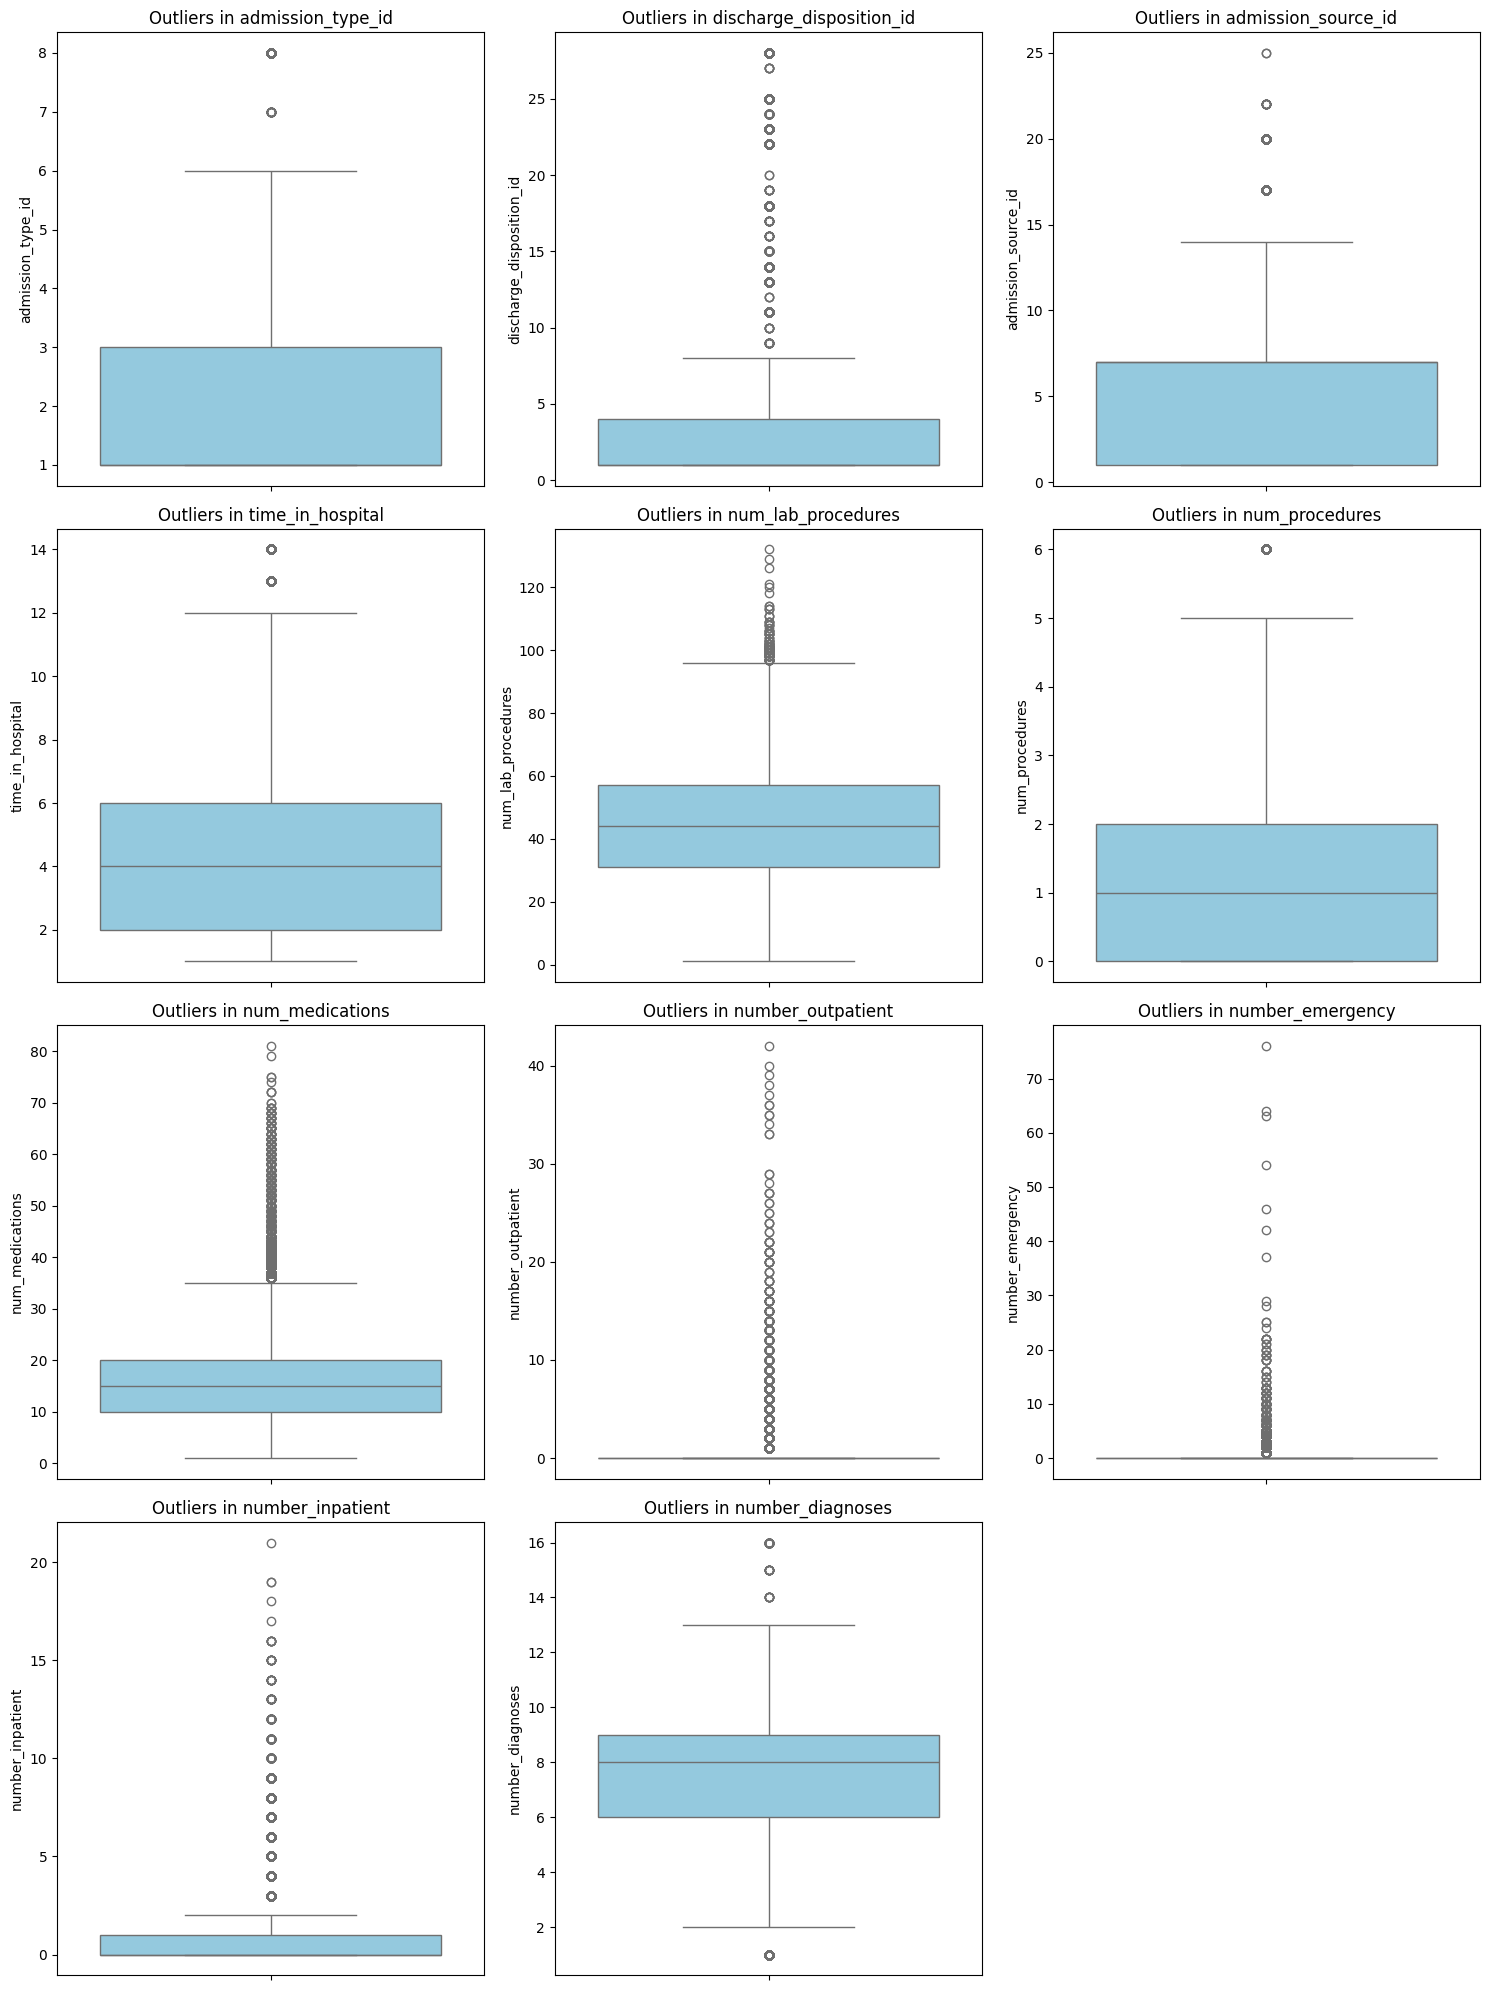

In [18]:
numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 3
rows = (n // cols) + (1 if n % cols > 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

In [19]:
numeric_cols_to_fix = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses'
]

for col in numeric_cols_to_fix:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Outliers Capping Completed Successfully.")

Outliers Capping Completed Successfully.


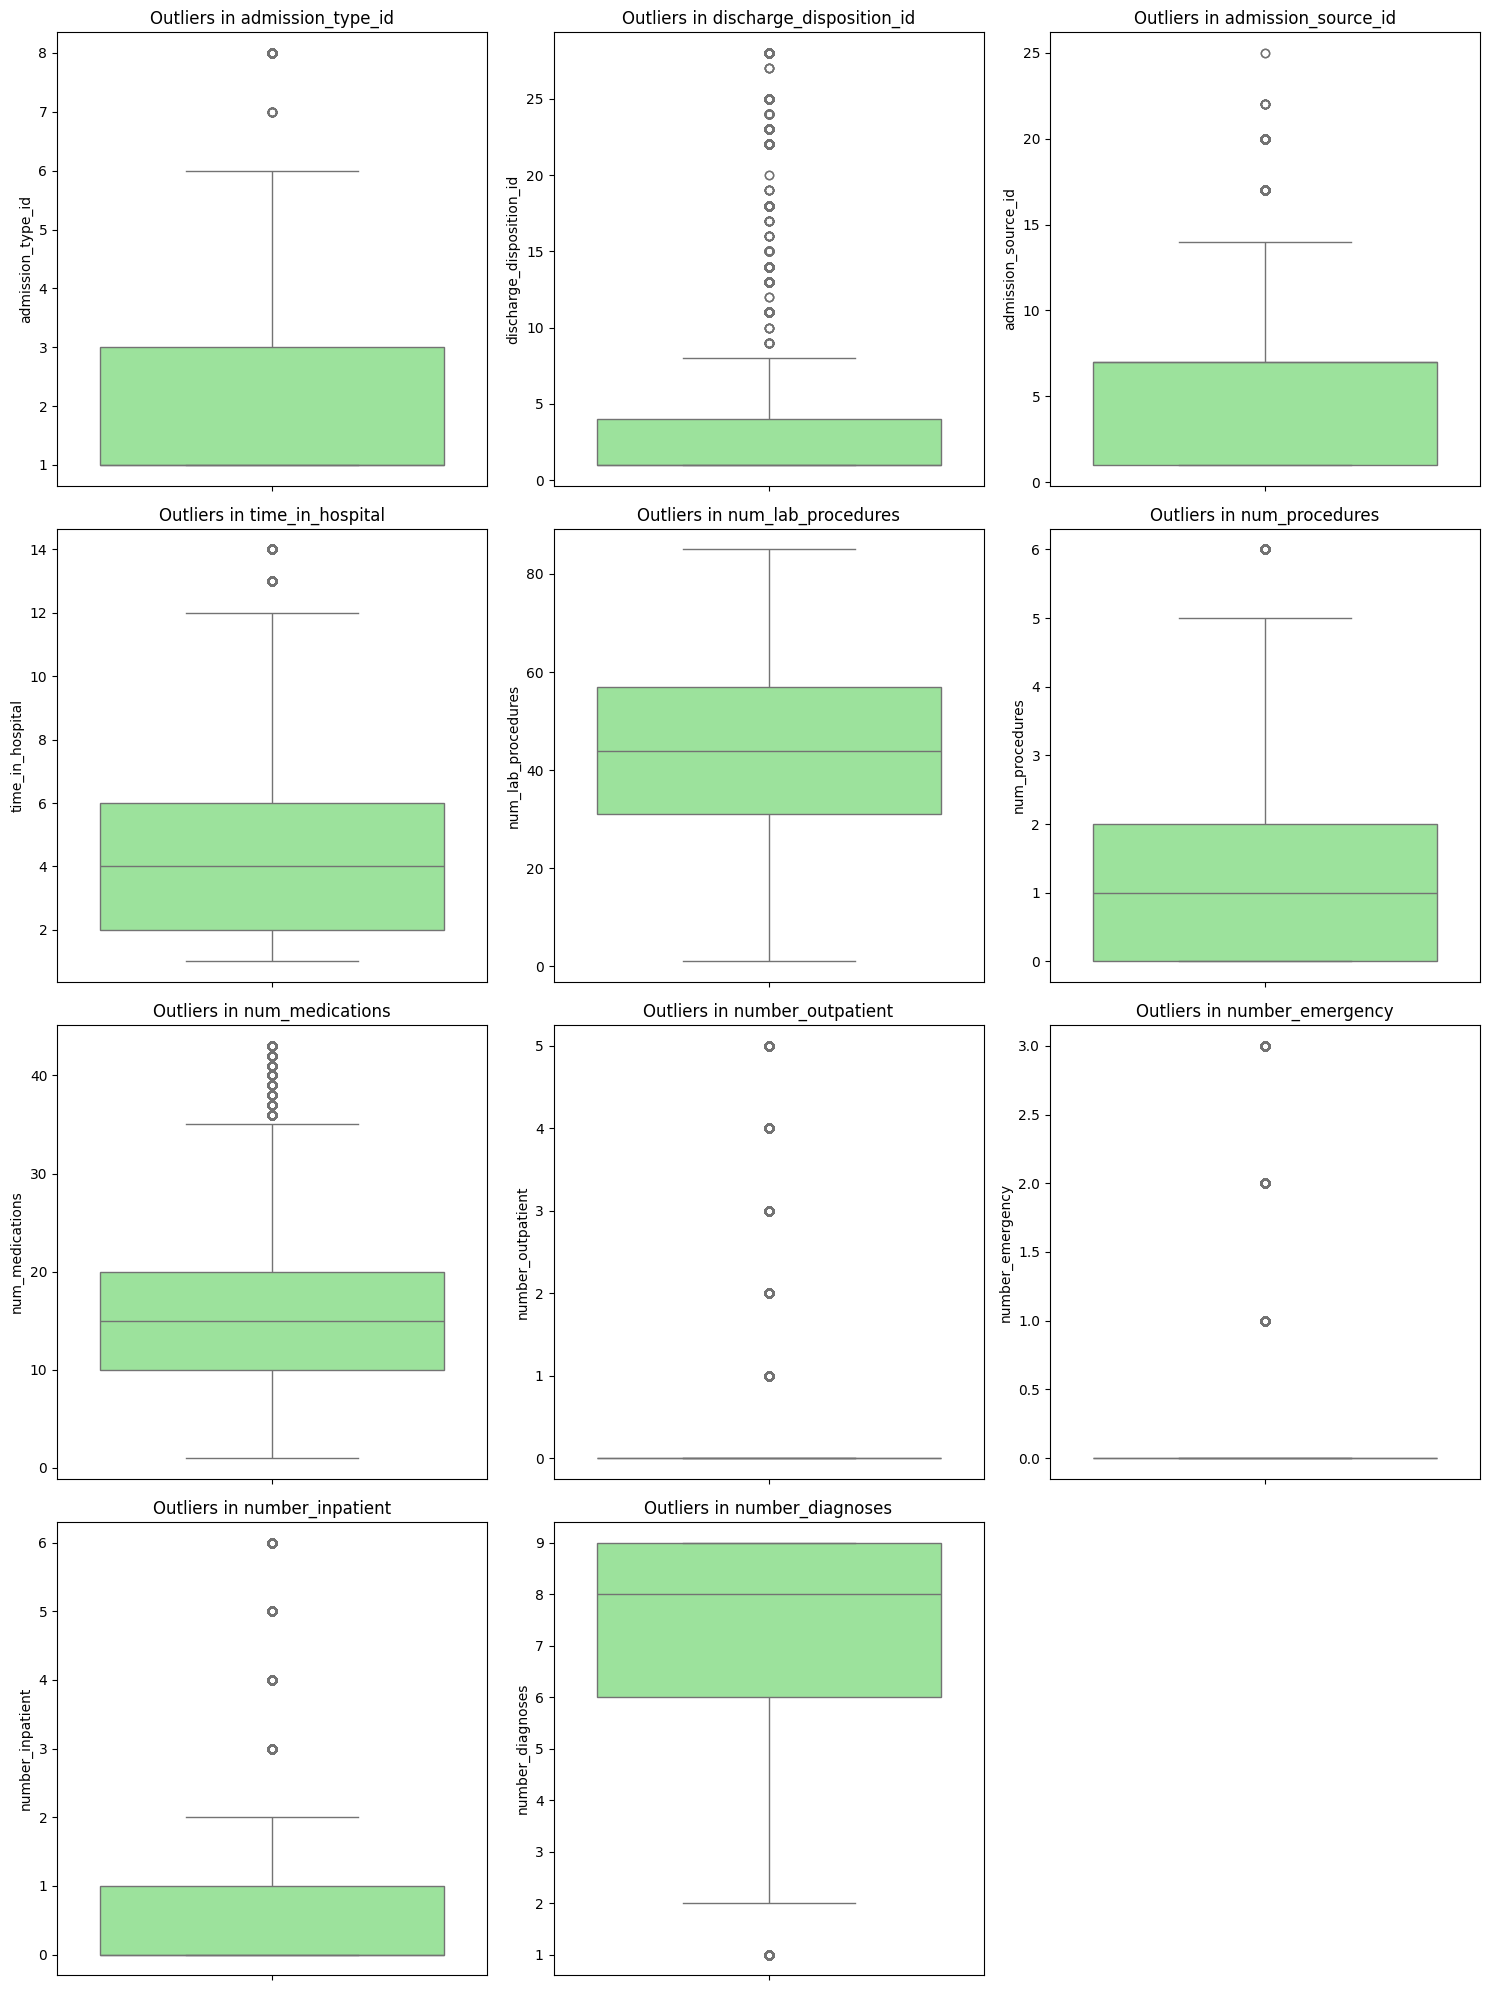

In [20]:
numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 3
rows = (n // cols) + (1 if n % cols > 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# ⚠️ Outliers Handling (Capping Method)

Outliers are extreme values that deviate significantly from the rest of the data and may affect the performance of machine learning models. In this project, instead of removing outliers, a **capping (Winsorization)** approach was used to reduce their impact while preserving the dataset size and information.

---

# 📌 Outliers Treatment Approach

## 🔹 Method Used: Capping at 99th Percentile

For each selected numerical feature, values above the 99th percentile were replaced with the 99th percentile value itself. This ensures that extreme values do not distort the overall distribution.

---

## 🔢 Features Applied

- time_in_hospital  
- num_lab_procedures  
- num_procedures  
- num_medications  
- number_outpatient  
- number_emergency  
- number_inpatient  
- number_diagnoses  

---

## 🧠 Process Explanation

- The 99th percentile (upper limit) was calculated for each feature  
- Values greater than this limit were capped  
- numpy `where` function was used for efficient replacement  

---

## 📊 Result

- Extreme values were controlled  
- Data distribution became more stable  
- No rows were removed from the dataset  
- Dataset remained intact for modeling  

---

## 🚀 Final Outcome

The dataset is now:
- Cleaned  
- Stable  
- Less affected by extreme values  
- Ready for machine learning models

# 📊 Univariate Analysis

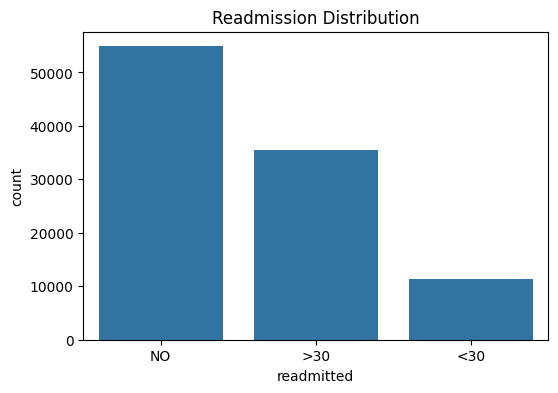

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

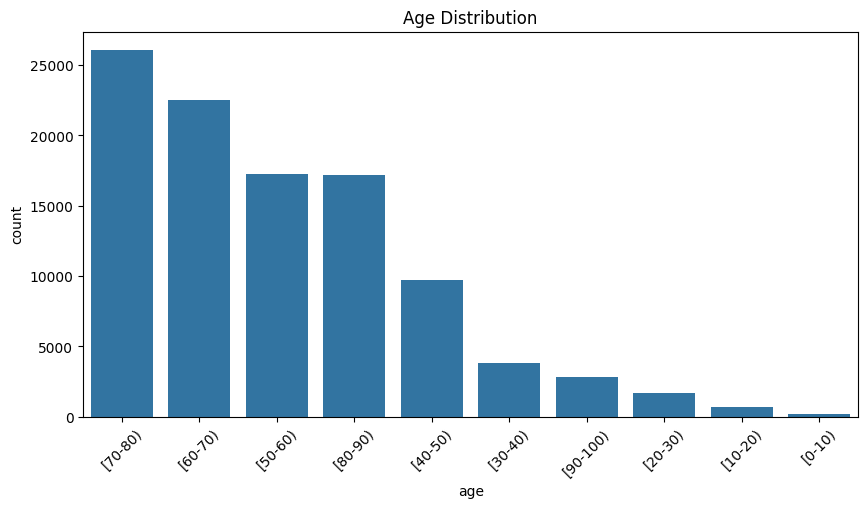

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', data=df, order=df['age'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

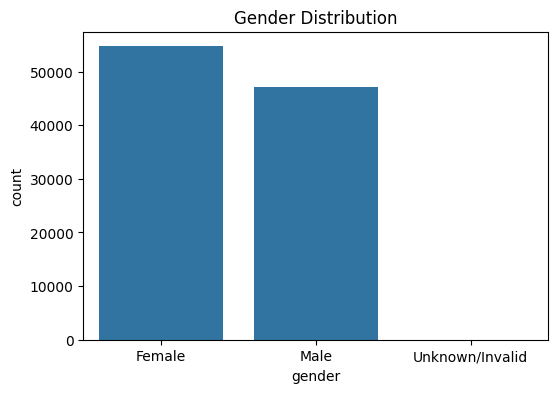

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

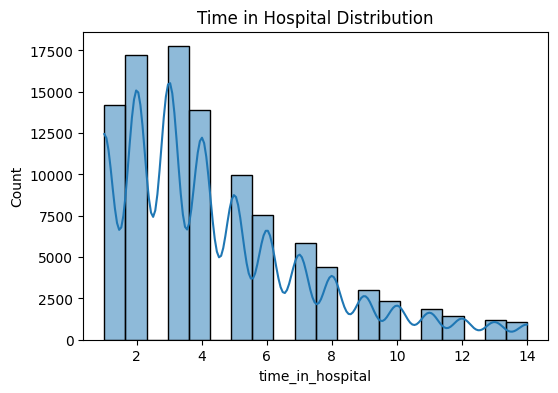

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['time_in_hospital'], bins=20, kde=True)
plt.title("Time in Hospital Distribution")
plt.show()

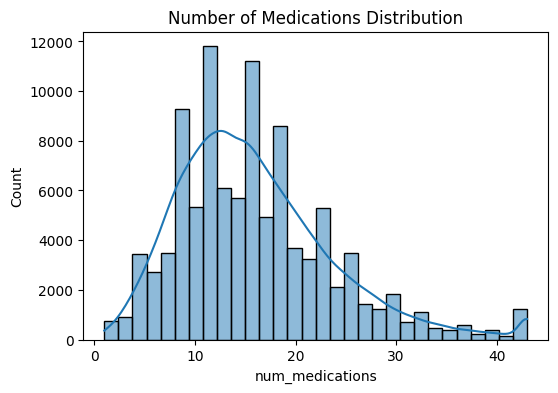

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_medications'], bins=30, kde=True)
plt.title("Number of Medications Distribution")
plt.show()

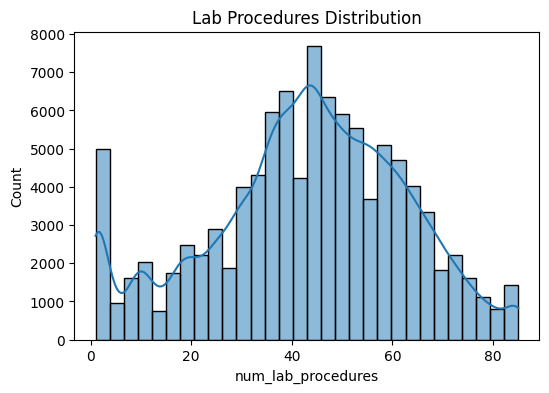

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_lab_procedures'], bins=30, kde=True)
plt.title("Lab Procedures Distribution")
plt.show()

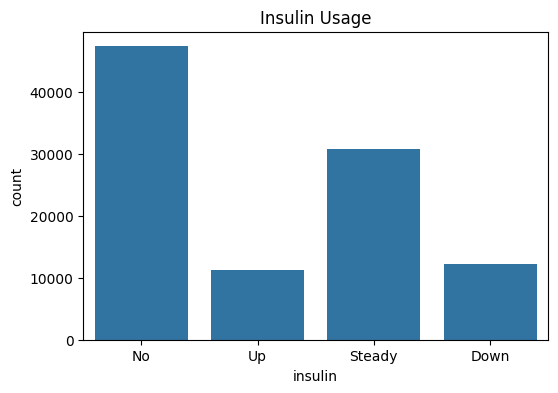

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', data=df)
plt.title("Insulin Usage")
plt.show()

# 📊 Bivariate Analysis

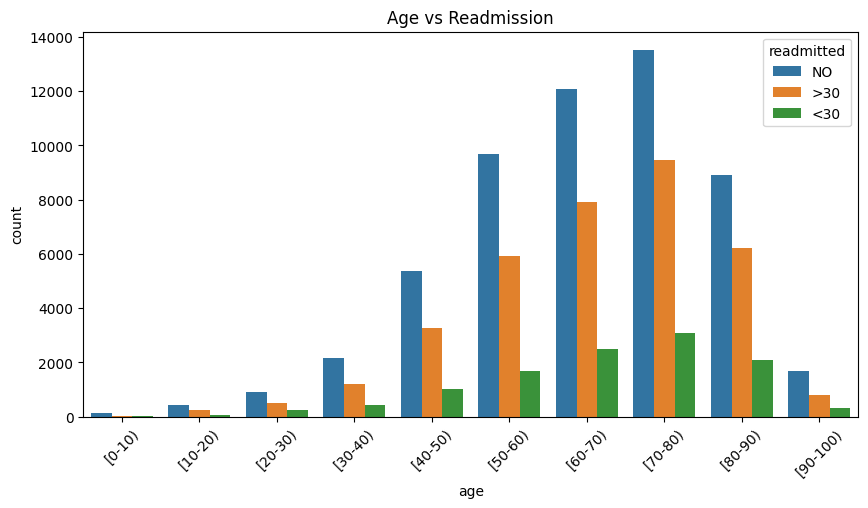

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Readmission")
plt.show()

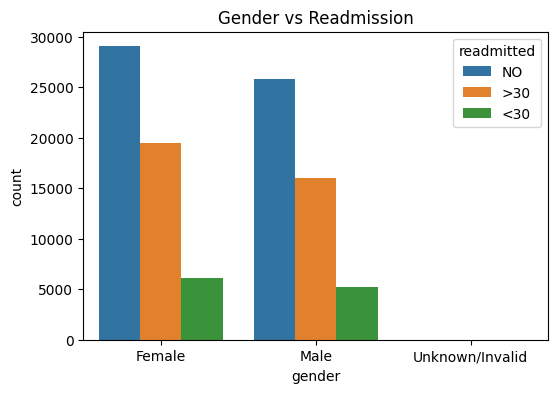

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title("Gender vs Readmission")
plt.show()

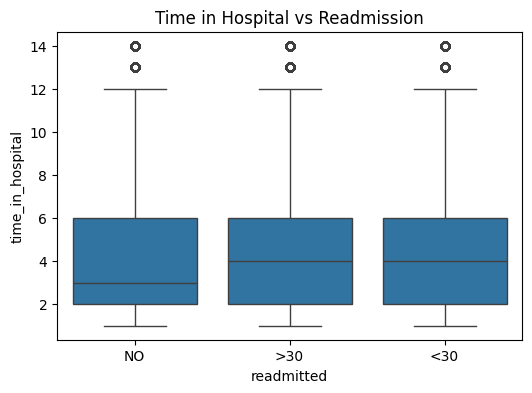

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title("Time in Hospital vs Readmission")
plt.show()

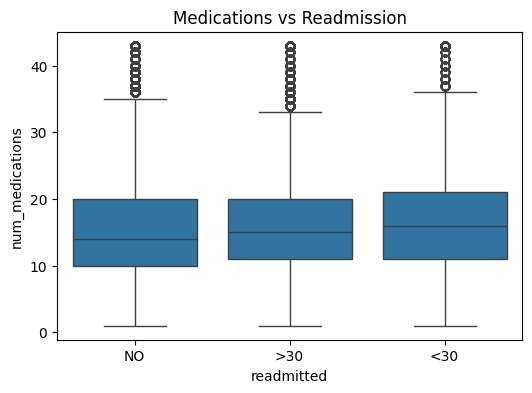

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='num_medications', data=df)
plt.title("Medications vs Readmission")
plt.show()

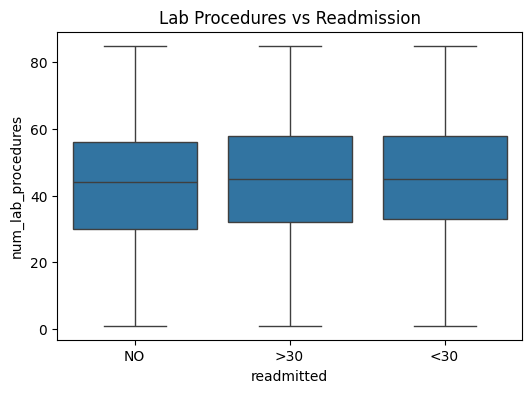

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='num_lab_procedures', data=df)
plt.title("Lab Procedures vs Readmission")
plt.show()

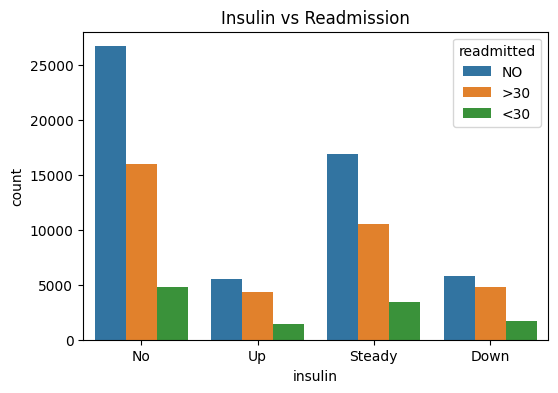

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', hue='readmitted', data=df)
plt.title("Insulin vs Readmission")
plt.show()

# 📊 Multivariate Analysis

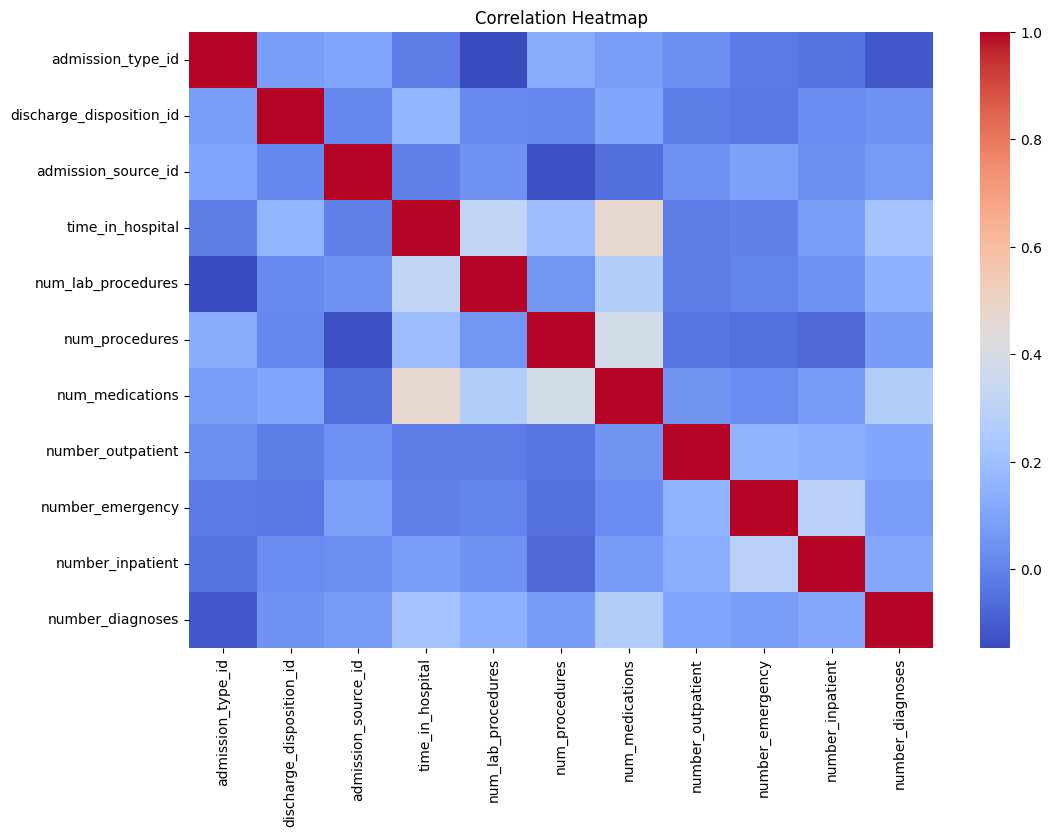

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

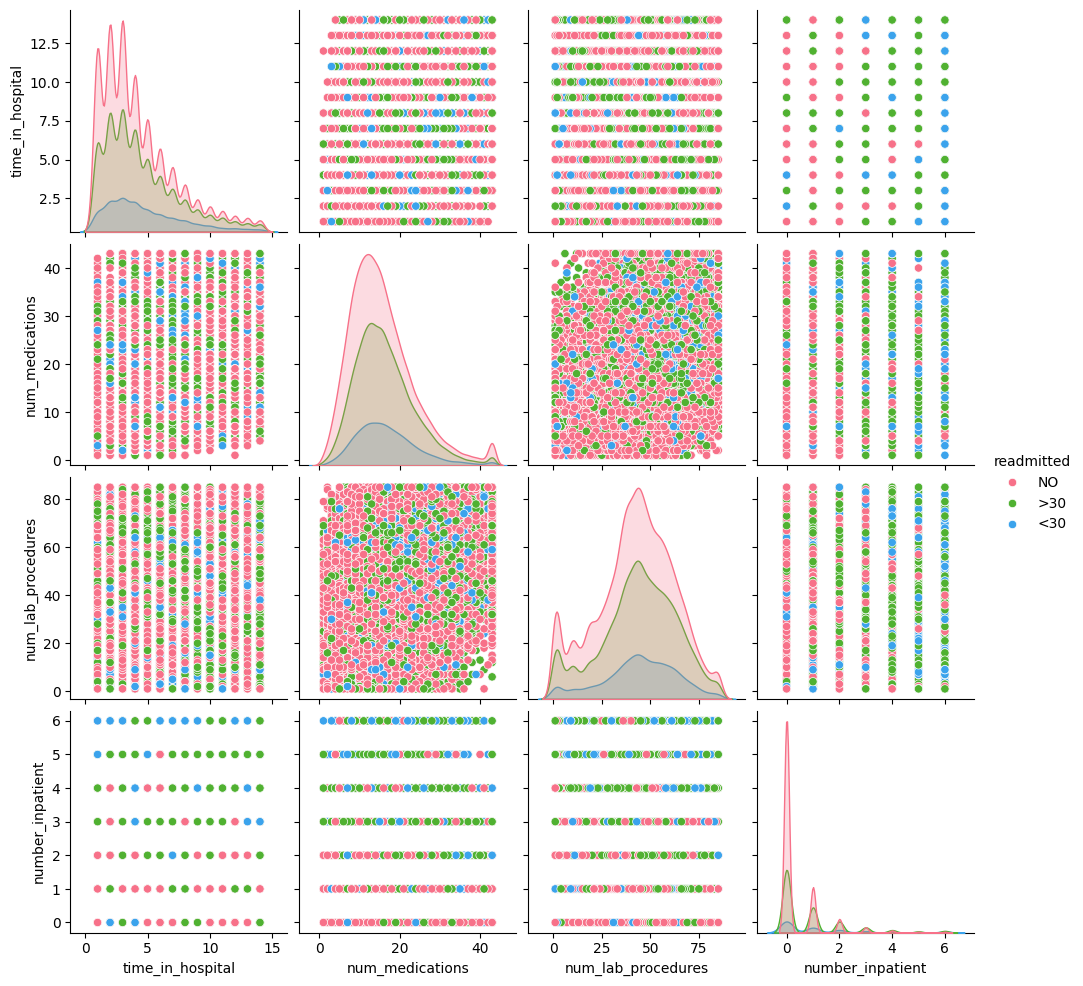

In [35]:
plot_df = df[['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_inpatient', 'readmitted']].copy()
plot_df['readmitted'] = plot_df['readmitted'].astype(str)

sns.pairplot(plot_df, hue='readmitted', palette='husl', diag_kind='kde')
plt.show()

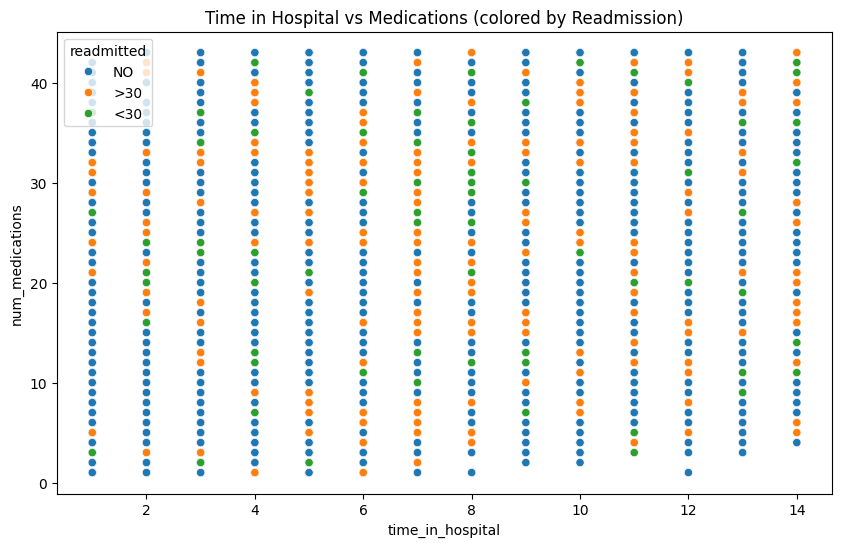

In [36]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='time_in_hospital',
    y='num_medications',
    hue='readmitted',
    data=df
)
plt.title("Time in Hospital vs Medications (colored by Readmission)")
plt.show()

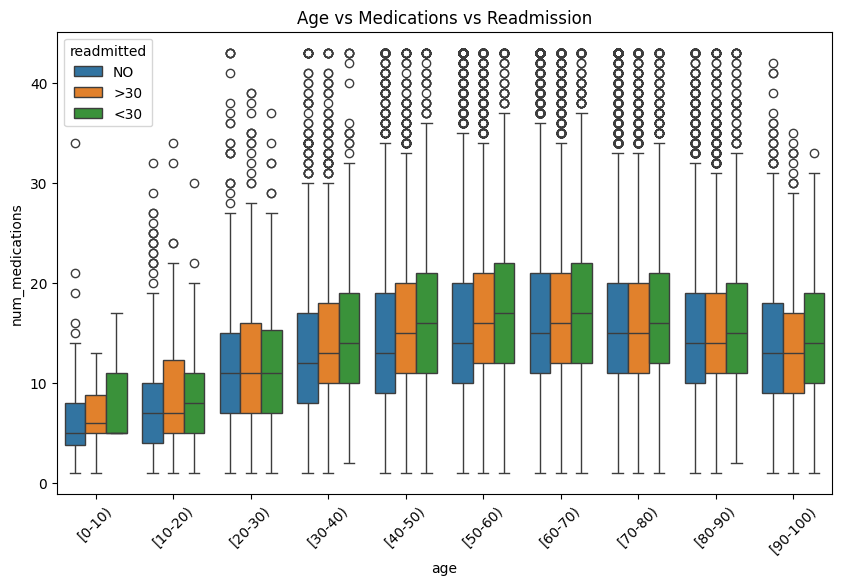

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='age',
    y='num_medications',
    hue='readmitted',
    data=df
)
plt.xticks(rotation=45)
plt.title("Age vs Medications vs Readmission")
plt.show()

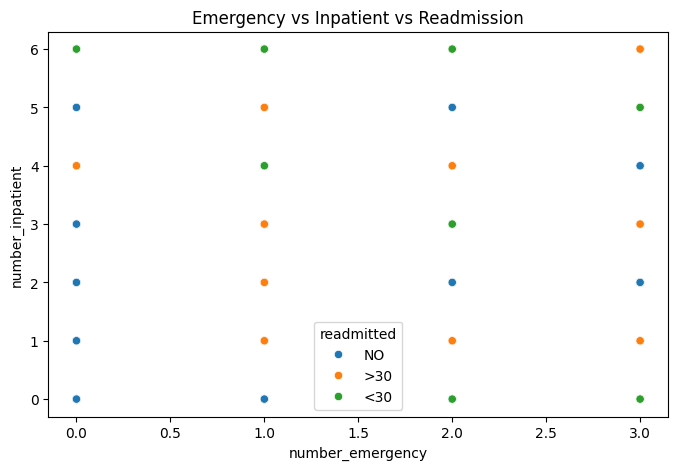

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='number_emergency',
    y='number_inpatient',
    hue='readmitted',
    data=df
)
plt.title("Emergency vs Inpatient vs Readmission")
plt.show()

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the structure, distribution, and relationships within the dataset. It helps in identifying patterns, trends, and insights before building machine learning models.

---

# 📌 1️⃣ Univariate Analysis

Univariate analysis was performed to understand the distribution of individual variables.

## 🔹 Target Variable Distribution
- The distribution of `readmitted` was analyzed to understand class imbalance.

## 🔹 Age Distribution
- Age groups were explored to understand patient distribution across different age ranges.

## 🔹 Gender Distribution
- Gender distribution was visualized to understand demographic balance.

## 🔹 Numerical Features Distribution
Histograms were used to analyze:

- time_in_hospital  
- num_medications  
- num_lab_procedures  

These helped in identifying skewness and spread in the data.

## 🔹 Insulin Usage
- Distribution of insulin medication usage was analyzed.

---

# 📌 2️⃣ Bivariate Analysis

Bivariate analysis was used to study relationships between features and the target variable.

## 🔹 Age vs Readmission
- Shows how readmission varies across different age groups.

## 🔹 Gender vs Readmission
- Explores relationship between gender and readmission.

## 🔹 Clinical Features vs Readmission
Boxplots were used for:

- time_in_hospital vs readmitted  
- num_medications vs readmitted  
- num_lab_procedures vs readmitted  

## 🔹 Insulin vs Readmission
- Shows relationship between insulin usage and readmission rates.

---

# 📌 3️⃣ Correlation Analysis

A correlation heatmap was used to identify relationships between numerical variables.

## 🔹 Purpose:
- Detect feature correlations  
- Understand dependencies between medical variables  

---

# 📌 4️⃣ Multivariate Analysis

Multivariate analysis was performed to explore interactions between multiple features.

## 🔹 Time in Hospital vs Medications vs Readmission
- Shows interaction between hospital stay duration and medication usage.

## 🔹 Age vs Medications vs Readmission
- Explores how age affects medication patterns and readmission.

## 🔹 Emergency vs Inpatient Visits vs Readmission
- Highlights relationship between emergency visits, inpatient admissions, and readmission risk.

---

# 📌 5️⃣ Pairplot Analysis (Enhanced)

A pairplot was used to visualize relationships between multiple numerical features simultaneously.

## 🔹 Features Used:
- time_in_hospital  
- num_medications  
- num_lab_procedures  
- number_inpatient  
- readmitted  

## 🔹 Enhancements Applied:
- `hue='readmitted'` was used to separate classes visually  
- `palette='husl'` was applied for better color distinction  
- `diag_kind='kde'` was used to show smooth density distributions on diagonal plots  

## 🔹 Insight:
- Helps in identifying clusters and patterns between variables  
- Shows how features interact across different readmission classes  
- Provides a deeper visual understanding of feature relationships  

---

# 🚀 Final Outcome

After performing EDA:

- Data distribution was understood  
- Feature relationships were identified  
- Class imbalance was analyzed  
- Strong visual insights were extracted  
- Dataset was fully prepared for machine learning modeling

# 📌 Encoding

In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
df = df.copy()

In [41]:
le_gender = LabelEncoder()

if 'gender' in df.columns:
    df['gender'] = le_gender.fit_transform(df['gender'].astype(str))

In [42]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

med_mapping = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': -1}

for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_mapping)

In [43]:
binary_mapping = {'No': 0, 'Yes': 1, 'Ch': 1}

for col in ['change', 'diabetesMed']:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)

In [44]:
categorical_cols = ['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

df = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], drop_first=True)

In [45]:
df['readmitted'] = df['readmitted'].map({
    'NO': 0,
    '<30': 1,
    '>30': 2
})

In [46]:
label_cols = ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']

for col in label_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [47]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

# 🔄 Feature Encoding

Feature encoding is an important preprocessing step in machine learning where categorical variables are converted into numerical format so that they can be understood by ML models.

In this project, multiple encoding techniques were applied based on the nature of each feature.

---

# 📌 Encoding Process

## 🔹 1️⃣ Gender Encoding (Label Encoding)

The `gender` column was converted into numerical values using Label Encoding.

- Male → 1  
- Female → 0  

This step was necessary to transform binary categorical data into a machine-readable format.

---

## 🔹 2️⃣ Medication Encoding (Ordinal Mapping)

Medication-related features were encoded using a custom ordinal mapping:

- No → 0  
- Steady → 1  
- Up → 2  
- Down → -1  

This preserves the severity or change direction in medication usage.

---

## 🔹 3️⃣ Binary Feature Encoding

Binary features were converted into numerical format using mapping:

- No → 0  
- Yes → 1  
- Ch → 1  

This was applied to features such as:
- change  
- diabetesMed  

---

## 🔹 4️⃣ One-Hot Encoding

Categorical features with multiple categories were transformed using One-Hot Encoding:

- race  
- admission_type_id  
- discharge_disposition_id  
- admission_source_id  

This prevents introducing any ordinal relationship between categories.

---

## 🔹 5️⃣ Label Encoding (Other Categorical Features)

High-cardinality categorical features were encoded using Label Encoding:

- age  
- medical_specialty  
- diag_1  
- diag_2  
- diag_3  
- max_glu_serum  
- A1Cresult  

Each category was assigned a unique numerical label.

---

## 🔹 6️⃣ Boolean Conversion

Boolean columns were converted into integer format:

- True → 1  
- False → 0  

---

# 🚀 Final Outcome

After applying encoding:

- All categorical features were converted into numerical format  
- Dataset became fully compatible with machine learning models  
- No object (string) columns remained in the dataset  
- Data is now ready for model training and evaluation